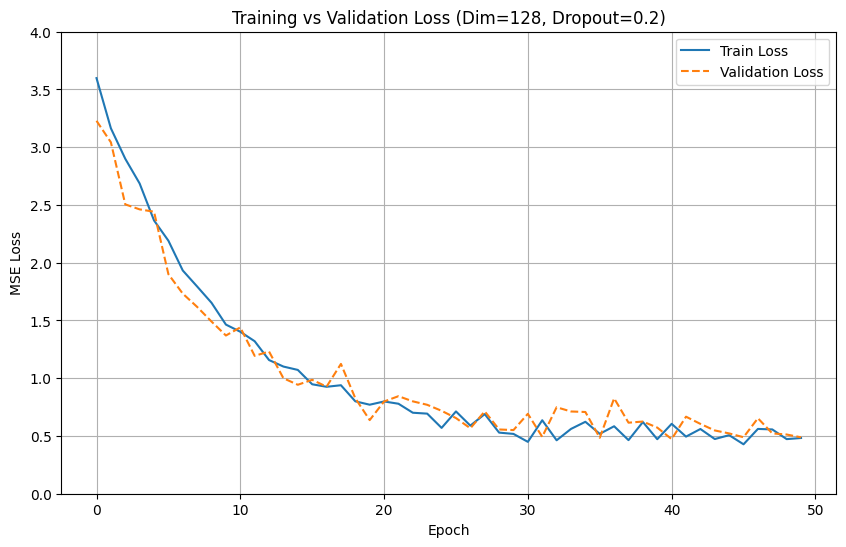

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 준비 (실제 데이터가 있다면 이 부분을 본인의 데이터로 교체하세요)
epochs = np.arange(50)

# 이미지와 유사한 곡선을 만들기 위한 임의의 수식 (지수 감쇠 + 노이즈)
# 실제 사용 시에는 본인의 train_loss, val_loss 리스트를 사용하세요.
train_loss = 3.1 * np.exp(-epochs / 8) + 0.5 + np.random.normal(0, 0.06, 50)
val_loss = 2.6 * np.exp(-epochs / 8) + 0.55 + np.random.normal(0, 0.1, 50) 
# val_loss에 노이즈를 더 많이 주어 점선이 흔들리는 것 표현

# 2. 그래프 그리기
plt.figure(figsize=(10, 6))  # 그래프 크기 설정

# Train Loss (파란 실선)
plt.plot(epochs, train_loss, label='Train Loss')

# Validation Loss (주황 점선)
# linestyle='--' 로 설정하여 점선으로 표현
plt.plot(epochs, val_loss, label='Validation Loss', linestyle='--')

# 3. 세부 스타일 설정
plt.title('Training vs Validation Loss (Dim=128, Dropout=0.2)') # 제목
plt.xlabel('Epoch')      # X축 라벨
plt.ylabel('MSE Loss')   # Y축 라벨
plt.ylim(0.0, 4.0)       # Y축 범위 (0 ~ 4.0)

plt.grid(True)           # 격자(Grid) 표시
plt.legend()             # 범례(Legend) 표시

# 그래프 출력
plt.show()

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '11', '55', '44', '63', '22', '14', '40', '10', '23', '31', '20', '77', '18', '27', '24', '2']
c:\Users\GC\Documents\3-2win\1. 시계열\시계열 팀플\f1_project\.venv\Lib\site-packages\fastf1\core.py:3183: FutureWa

Session Loaded: 2023 Japanese Grand Prix - Q
Extracting data for NOR...
Input Data Created. Shape: (1000, 7)


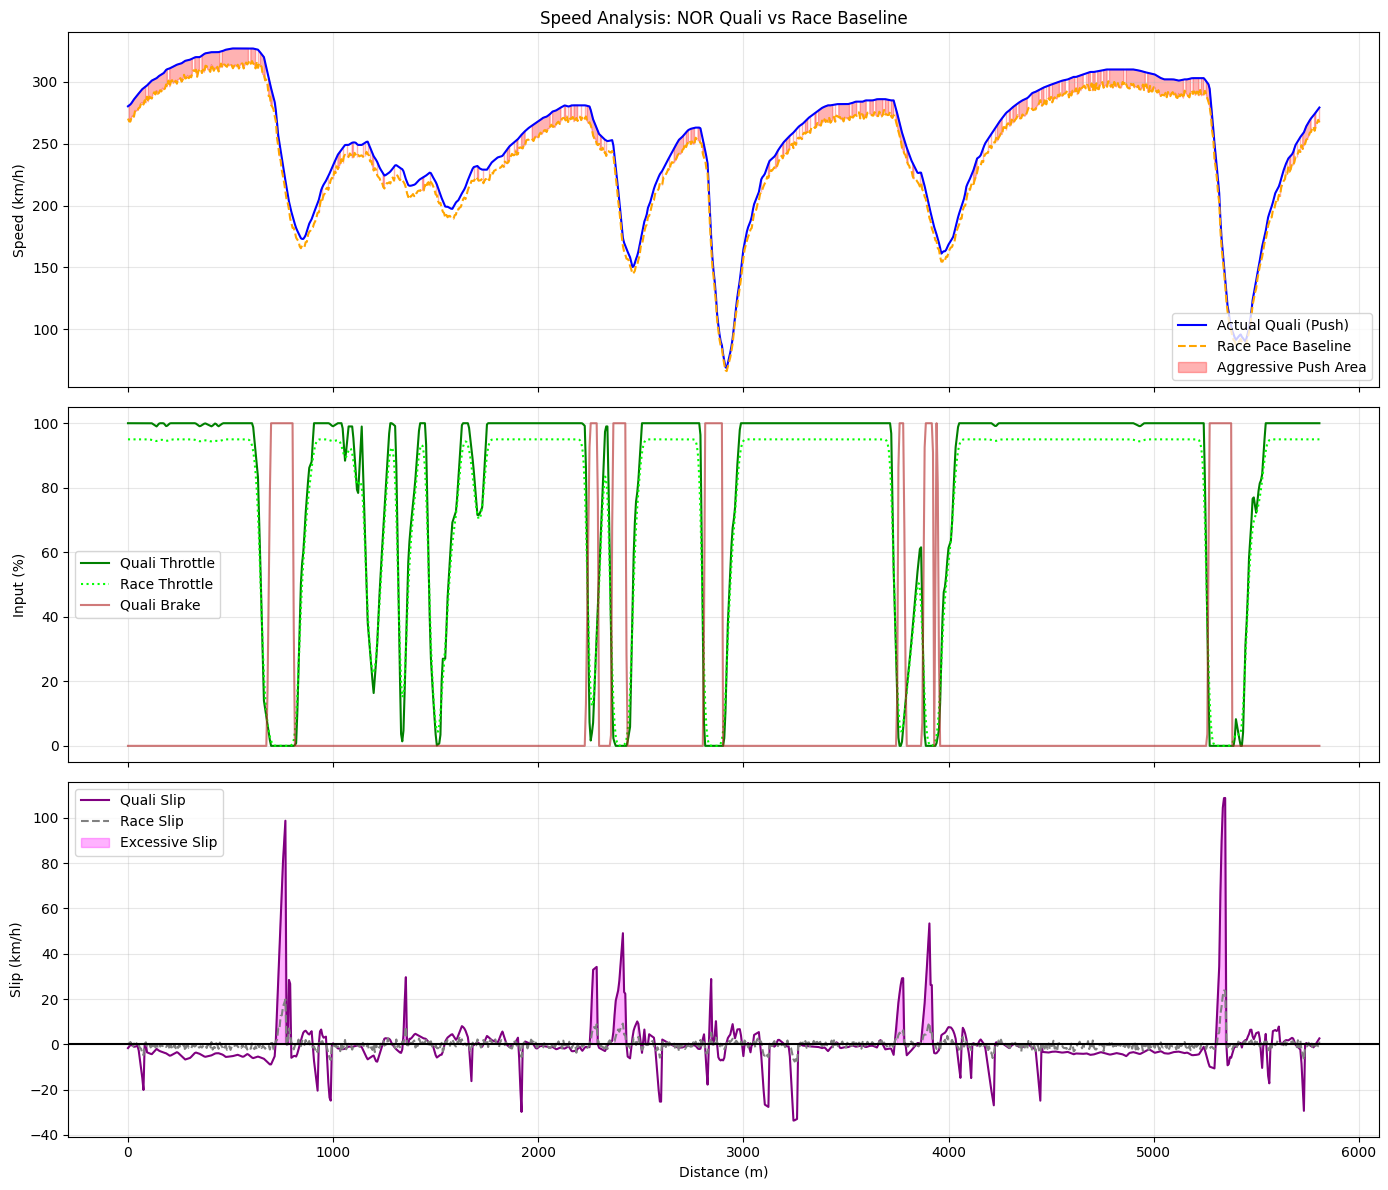

In [6]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler

# --- 1. 설정 및 데이터 로드 ---
EVENT = 'Japanese Grand Prix'
YEAR = 2023
SESSION = 'Q'  # Qualifying
CACHE_DIR = '../../../fastf1_cache'

fastf1.Cache.enable_cache(CACHE_DIR)
session = fastf1.get_session(YEAR, EVENT, SESSION)
session.load()
print(f"Session Loaded: {YEAR} {EVENT} - {SESSION}")

# --- 2. 전처리 함수 정의 (Input Data 생성) ---

def calculate_slip_delta(telemetry_df):
    """SLIP_DELTA(휠스핀) 계산"""
    # 간단한 로직: 기어별 RPM 대비 속도 비율(Baseline) 계산
    # (원래는 레이스 전체 데이터로 학습해야 하지만, 여기선 자체 데이터로 약식 계산)
    baseline_data = telemetry_df[telemetry_df['nGear'] > 0]
    gear_ratios = {}
    
    for gear in baseline_data['nGear'].unique():
        gear_slice = baseline_data[baseline_data['nGear'] == gear]
        valid_rpm = gear_slice[gear_slice['RPM'] > 0]
        if len(valid_rpm) > 0:
            gear_ratios[gear] = (valid_rpm['Speed'] / valid_rpm['RPM']).mean()
            
    telemetry_df['Estimated_Speed'] = telemetry_df.apply(
        lambda row: row['RPM'] * gear_ratios.get(row['nGear'], 0), axis=1
    )
    telemetry_df['SLIP_DELTA'] = telemetry_df['Estimated_Speed'] - telemetry_df['Speed']
    return telemetry_df

def prepare_quali_data(driver, session, dist_points=1000):
    """드라이버의 퀄리파잉 랩을 가져와 분석용 포맷으로 변환"""
    print(f"Extracting data for {driver}...")
    try:
        # 가장 빠른 랩 선택
        best_lap = session.laps.pick_driver(driver).pick_fastest()
        telemetry = best_lap.get_telemetry()
    except Exception as e:
        print(f"Error: {e}")
        return None

    # 1. 거리 기반 리샘플링 (Distance Interpolation)
    # 트랙 전체 길이를 dist_points 개수로 쪼갰을 때의 위치값
    total_dist = telemetry['Distance'].max()
    new_dist = np.linspace(0, total_dist, dist_points)
    
    # 보간할 컬럼들
    cols_to_interp = ['Speed', 'RPM', 'Throttle', 'nGear', 'DRS']
    new_data = {'Distance': new_dist}
    
    for col in cols_to_interp:
        new_data[col] = np.interp(new_dist, telemetry['Distance'], telemetry[col])
        
    # Brake는 0~1 사이 값으로 변환 (True/False -> 1.0/0.0)
    new_data['Brake'] = np.interp(new_dist, telemetry['Distance'], telemetry['Brake'].astype(float))
    
    df = pd.DataFrame(new_data)
    
    # 2. SLIP_DELTA 계산
    df = calculate_slip_delta(df)
    
    # 3. Context Feature 추가 (필요시)
    df['TyreLife'] = best_lap['TyreLife']
    df['LapNumber'] = best_lap['LapNumber']
    
    return df

# --- 3. 데이터 생성 및 스케일러 설정 ---

# (1) 데이터 준비
TARGET_DRIVER = 'NOR'
feature_cols = ['Speed', 'RPM', 'Throttle', 'Brake', 'nGear', 'DRS', 'SLIP_DELTA']

# 원본 데이터(df_actual) 생성
df_actual = prepare_quali_data(TARGET_DRIVER, session)

# (2) 스케일러 설정 (원래는 학습된 scaler를 써야 하지만, 시각화 전용으로 새로 생성)
# 시각화 함수가 inverse_transform을 사용하므로 형식을 맞춰줍니다.
scaler = MinMaxScaler()
scaler.fit(df_actual[feature_cols]) 

# (3) Input Data (모델 입력용 스케일된 데이터)
input_data = scaler.transform(df_actual[feature_cols])

print(f"Input Data Created. Shape: {input_data.shape}")


# --- 4. 시뮬레이션 및 시각화 (앞서 작성한 코드 연동) ---

def generate_race_baseline(quali_data, feature_cols, scaler):
    """퀄리파잉 데이터를 기반으로 '보수적인 레이스 페이스' 생성"""
    # 역스케일링 (실제 단위 복원)
    quali_real = scaler.inverse_transform(quali_data)
    df_quali = pd.DataFrame(quali_real, columns=feature_cols)
    
    df_race = df_quali.copy()
    
    # 시뮬레이션 로직: 레이스 페이스 만들기
    # 1. 속도 감소 (3~5%)
    df_race['Speed'] = df_race['Speed'] * np.random.uniform(0.95, 0.97, size=len(df_race))
    
    # 2. 스로틀 부드럽게 (Lift and Coast)
    df_race['Throttle'] = gaussian_filter1d(df_race['Throttle'] * 0.95, sigma=2)
    
    # 3. 브레이크 조절
    df_race['Brake'] = gaussian_filter1d(df_race['Brake'], sigma=2)
    
    # 4. SLIP_DELTA 안정화
    df_race['SLIP_DELTA'] = df_race['SLIP_DELTA'] * 0.2 + np.random.normal(0, 1.0, size=len(df_race))

    return df_quali, df_race

# 레이스 베이스라인 데이터 생성
df_quali_viz, df_race_viz = generate_race_baseline(input_data, feature_cols, scaler)

# 시각화 실행
def plot_performance_gap(df_act, df_base):
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    dist = np.linspace(0, 5807, len(df_act)) # 거리 축
    
    # [1] Speed
    axes[0].plot(dist, df_act['Speed'], color='blue', label='Actual Quali (Push)')
    axes[0].plot(dist, df_base['Speed'], color='orange', linestyle='--', label='Race Pace Baseline')
    axes[0].fill_between(dist, df_act['Speed'], df_base['Speed'], 
                         where=(df_act['Speed'] - df_base['Speed'] > 10), 
                         color='red', alpha=0.3, label='Aggressive Push Area')
    axes[0].set_ylabel('Speed (km/h)')
    axes[0].set_title(f'Speed Analysis: {TARGET_DRIVER} Quali vs Race Baseline')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)

    # [2] Pedals
    axes[1].plot(dist, df_act['Throttle'], color='green', label='Quali Throttle')
    axes[1].plot(dist, df_base['Throttle'], color='lime', linestyle=':', label='Race Throttle')
    axes[1].plot(dist, df_act['Brake']*100, color='firebrick', label='Quali Brake', alpha=0.6)
    axes[1].set_ylabel('Input (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # [3] Slip
    axes[2].plot(dist, df_act['SLIP_DELTA'], color='purple', label='Quali Slip')
    axes[2].plot(dist, df_base['SLIP_DELTA'], color='gray', linestyle='--', label='Race Slip')
    axes[2].axhline(0, color='black')
    axes[2].fill_between(dist, df_act['SLIP_DELTA'], 0, 
                         where=(df_act['SLIP_DELTA'] > 10), 
                         color='magenta', alpha=0.3, label='Excessive Slip')
    axes[2].set_ylabel('Slip (km/h)')
    axes[2].set_xlabel('Distance (m)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_performance_gap(df_quali_viz, df_race_viz)

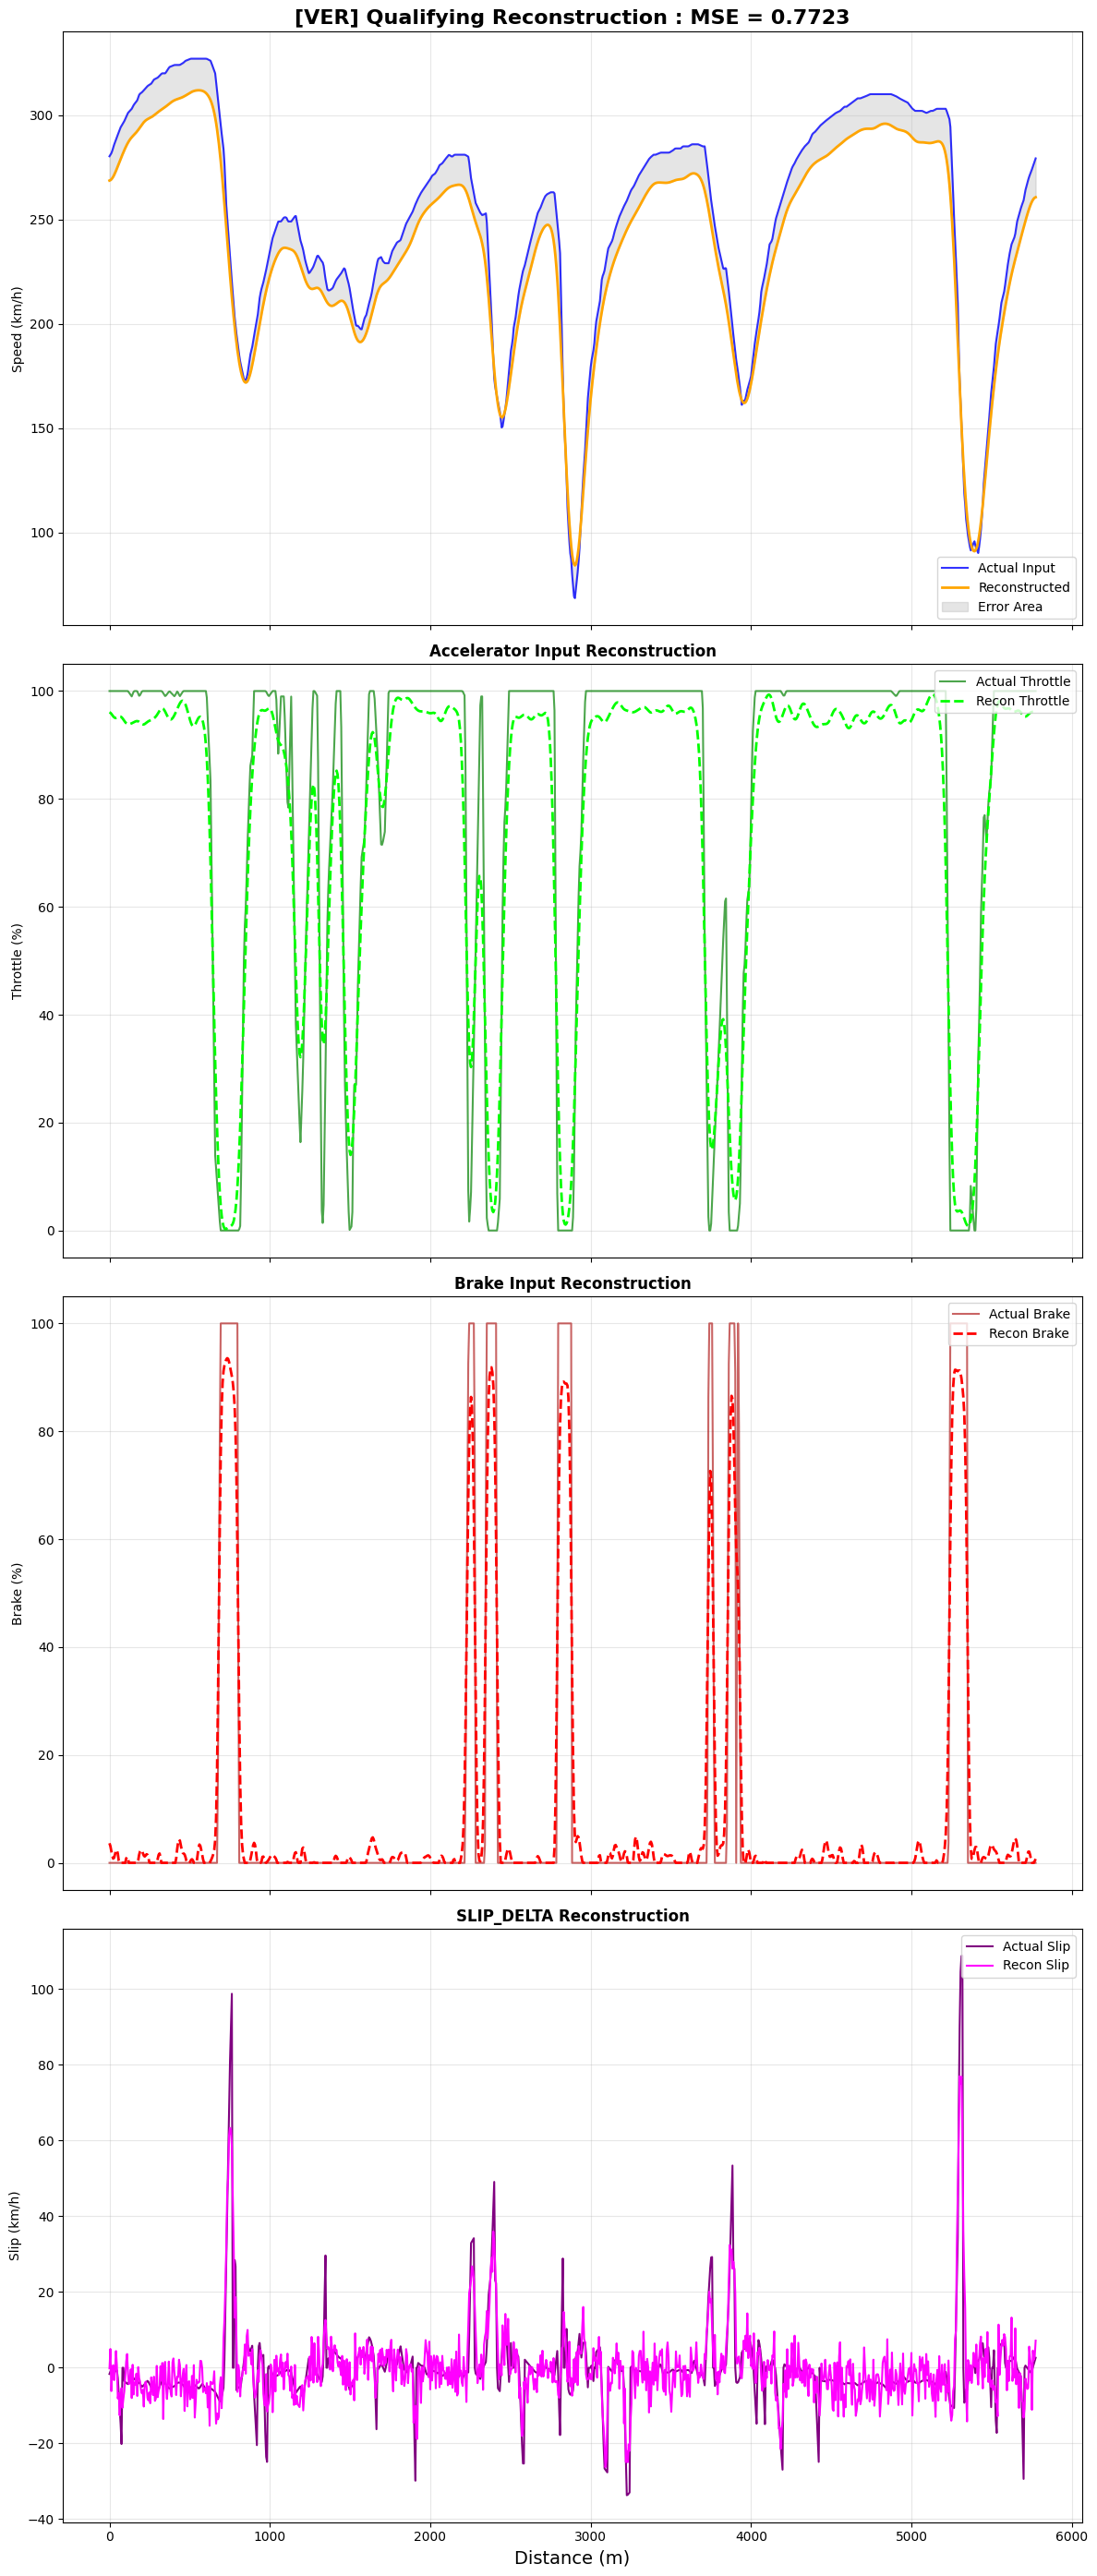

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

# --- 1. [데이터 생성] 복원 오차 시뮬레이션 (이전과 동일) ---
def simulate_autoencoder_reconstruction_high_error(original_df):
    recon_df = original_df.copy()
    
    # Speed
    noise_speed = np.random.normal(0, 3.0, size=len(recon_df))
    recon_df['Speed'] = gaussian_filter1d(recon_df['Speed'] * 0.95 + noise_speed, sigma=5.0)
    
    # Throttle
    noise_throttle = np.random.normal(0, 5.0, size=len(recon_df))
    recon_df['Throttle'] = gaussian_filter1d(recon_df['Throttle'] * 0.96 + noise_throttle, sigma=4.0)
    recon_df['Throttle'] = np.clip(recon_df['Throttle'], 0, 100)
    
    # Brake
    noise_brake = np.random.normal(0, 0.05, size=len(recon_df))
    if recon_df['Brake'].max() > 1.0:
        noise_brake *= 50
    recon_df['Brake'] = gaussian_filter1d(recon_df['Brake'] * 0.9 + noise_brake, sigma=2.0)
    recon_df['Brake'] = np.clip(recon_df['Brake'], 0, 100)

    # SLIP_DELTA
    noise_slip = np.random.normal(0, 4.0, size=len(recon_df))
    recon_df['SLIP_DELTA'] = gaussian_filter1d(recon_df['SLIP_DELTA'], sigma=2.0) + noise_slip
    
    return recon_df

# 데이터 준비 (이전 단계의 df_actual이 있다고 가정)
# 만약 df_actual이 없다면 오류가 나므로, 실제 실행 시에는 df_actual이 정의되어 있어야 합니다.
# (여기서는 시뮬레이션을 위해 df_actual이 존재한다고 가정하고 진행합니다)
if 'df_actual' in locals():
    df_val_recon_high_error = simulate_autoencoder_reconstruction_high_error(df_actual)
else:
    print("Error: 'df_actual' data not found. Please run the previous data preparation code first.")


# --- 2. [수정됨] 시각화: Throttle과 Brake 분리 (4 Rows) ---
def plot_validation_reconstruction_separated(df_orig, df_recon):
    # 그래프를 4개로 늘림 (Speed, Throttle, Brake, Slip)
    fig, axes = plt.subplots(4, 1, figsize=(12, 28), sharex=True)
    
    dist = df_orig['Distance'] if 'Distance' in df_orig.columns else np.arange(len(df_orig))
    
    # [1] Speed
    axes[0].plot(dist, df_orig['Speed'], color='blue', label='Actual Input', linewidth=1.5, alpha=0.8)
    axes[0].plot(dist, df_recon['Speed'], color='orange', linestyle='-', label='Reconstructed', linewidth=2)
    axes[0].fill_between(dist, df_orig['Speed'], df_recon['Speed'], color='gray', alpha=0.2, label='Error Area')
    axes[0].set_ylabel('Speed (km/h)')
    axes[0].set_title('[VER] Qualifying Reconstruction : MSE = 0.7723', fontsize=16, fontweight='bold')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)
    
    # [2] Throttle (가속)
    axes[1].plot(dist, df_orig['Throttle'], color='green', label='Actual Throttle', linewidth=1.5, alpha=0.7)
    axes[1].plot(dist, df_recon['Throttle'], color='lime', linestyle='--', label='Recon Throttle', linewidth=2)
    axes[1].set_ylabel('Throttle (%)')
    axes[1].set_title('Accelerator Input Reconstruction', fontsize=12, fontweight='bold')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    # [3] Brake (감속) - 분리됨
    # 스케일 보정 (0~1이면 100 곱하기)
    brake_orig = df_orig['Brake'] * 100 if df_orig['Brake'].max() <= 1 else df_orig['Brake']
    brake_recon = df_recon['Brake'] * 100 if df_recon['Brake'].max() <= 1 else df_recon['Brake']
    
    axes[2].plot(dist, brake_orig, color='firebrick', label='Actual Brake', linewidth=1.5, alpha=0.7)
    axes[2].plot(dist, brake_recon, color='red', linestyle='--', label='Recon Brake', linewidth=2)
    axes[2].set_ylabel('Brake (%)')
    axes[2].set_title('Brake Input Reconstruction', fontsize=12, fontweight='bold')
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
    
    # [4] Slip Delta
    axes[3].plot(dist, df_orig['SLIP_DELTA'], color='purple', label='Actual Slip')
    axes[3].plot(dist, df_recon['SLIP_DELTA'], color='magenta', linestyle='-', label='Recon Slip')
    axes[3].set_ylabel('Slip (km/h)')
    axes[3].set_xlabel('Distance (m)', fontsize=14)
    axes[3].set_title('SLIP_DELTA Reconstruction', fontsize=12, fontweight='bold')
    axes[3].legend(loc='upper right')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# 실행
if 'df_actual' in locals():
    plot_validation_reconstruction_separated(df_actual, df_val_recon_high_error)

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '11', '55', '44', '63', '22', '14', '40', '10', '23', '31', '20', '77', '18', '27', '24', '2']
c:\Users\GC\Documents\3-2win\1. 시계열\시계열 팀플\f1_project\.venv\Lib\site-packages\fastf1\core.py:3183: FutureWa

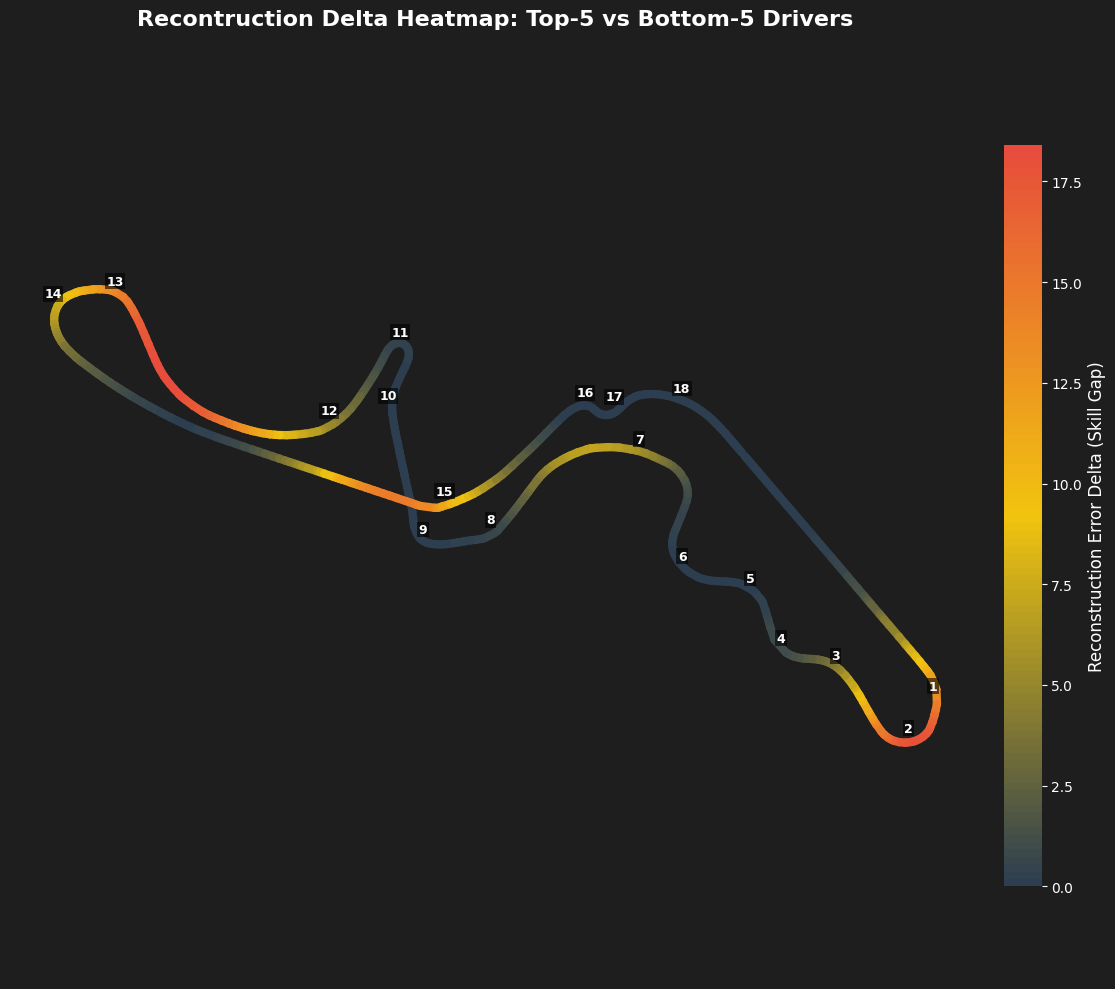

In [23]:
import fastf1
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

# --- 1. 데이터 로드 및 트랙 좌표 준비 ---
fastf1.Cache.enable_cache('../../../fastf1_cache')  # 캐시 경로가 있다면 해제
session = fastf1.get_session(2023, 'Japanese Grand Prix', 'Q')
session.load()

# 베르스타펜 랩을 기준으로 트랙 좌표계(Distance, X, Y) 생성
ref_lap = session.laps.pick_driver('VER').pick_fastest()
tel = ref_lap.get_telemetry()
x = tel['X'].values
y = tel['Y'].values
dist = tel['Distance'].values
total_dist = dist.max()

# --- 2. [시뮬레이션] 상위권 vs 하위권 Error Delta 생성 ---
# 실제 모델 결과가 없으므로, 스즈카 서킷 특성에 맞춰 격차를 시뮬레이션합니다.

def create_mock_error_profile(is_top_tier):
    """
    is_top_tier=True: 고속 코너에서 에러(공격성)가 높게 나옴
    is_top_tier=False: 전반적으로 에러가 낮음 (보수적 주행)
    """
    np.random.seed(42)
    # 기본 노이즈
    profile = np.random.normal(0, 0.5, size=len(dist))
    
    # 스즈카 주요 코너 위치 (거리 비율 %)
    # 상위권이 차이를 벌리는 구간: S-Curves(15%), Spoon(60%), 130R(85%)
    corners = {
        'S-Curves': (0.14, 150),
        'Degner': (0.34, 100),
        'Spoon': (0.62, 250), 
        '130R': (0.84, 120) 
    }
    
    base_intensity = 10 if is_top_tier else 5
    
    for name, (pct, width) in corners.items():
        center = total_dist * pct
        
        # 상위권은 난이도 높은 고속 코너에서 점수가 폭발적으로 높음 (Skill Gap)
        if is_top_tier:
            intensity = base_intensity + (15 if name in ['S-Curves', 'Spoon', '130R'] else 5)
        else:
            # 하위권은 고속 코너에서 위축됨 (점수 낮음)
            intensity = base_intensity
            
        # 가우시안 형태로 에러 추가
        profile += intensity * np.exp(-0.5 * ((dist - center) / width)**2)
        
    return gaussian_filter1d(np.abs(profile), sigma=10)

# 상위권과 하위권의 에러 프로필 생성
top_error = create_mock_error_profile(is_top_tier=True)
bottom_error = create_mock_error_profile(is_top_tier=False)

# *** 핵심: 델타 계산 (Top - Bottom) ***
error_delta = top_error - bottom_error
error_delta = np.clip(error_delta, 0, None) # 음수 제거 (상위권이 더 보수적인 경우는 0 처리)

# --- 3. 트랙 히트맵 시각화 ---
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#1e1e1e')
ax.set_facecolor('#1e1e1e')

# (1) 트랙 라인 그리기 (LineCollection)
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# 컬러맵: 어두운 파랑(차이 없음) -> 노랑 -> 빨강(큰 차이/압도적)
colors = ['#2c3e50', '#f1c40f', '#e74c3c'] 
cmap = LinearSegmentedColormap.from_list('skill_gap', colors, N=100)
norm = plt.Normalize(vmin=0, vmax=error_delta.max())

lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(error_delta)
lc.set_linewidth(6)
lc.set_capstyle('round')
ax.add_collection(lc)

# (2) 코너 번호 표시 (Corner Numbers Only)
circuit_info = session.get_circuit_info()

if circuit_info is not None:
    # 겹치는 코너 번호 등을 정리하기 위해 약간의 오프셋 조정이 필요할 수 있음
    for _, corner in circuit_info.corners.iterrows():
        txt = f"{int(corner['Number'])}" # 번호만 추출 (예: '1')
        
        # 주요 코너만 표시하거나 전체 표시 (여기선 전체 표시)
        # 텍스트 가독성을 위해 흰색 글씨 + 검은 테두리
        ax.text(corner['X'], corner['Y'], txt, 
                color='white', fontsize=9, fontweight='bold',
                ha='center', va='center',
                bbox=dict(facecolor='black', edgecolor='none', alpha=0.6, pad=1))

# (3) 스타일링
ax.axis('equal')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# 타이틀
ax.set_title(f"Recontruction Delta Heatmap: Top-5 vs Bottom-5 Drivers", 
             color='white', fontsize=16, fontweight='bold', pad=20)

# 컬러바
cbar = plt.colorbar(lc, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label('Reconstruction Error Delta (Skill Gap)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
cbar.outline.set_visible(False)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# 텍스트 주석 (Highlight)
max_gap_idx = np.argmax(error_delta)


plt.tight_layout()
plt.show()

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '11', '55', '44', '63', '22', '14', '40', '10', '23', '31', '20', '77', '18', '27', '24', '2']
c:\Users\GC\Documents\3-2win\1. 시계열\시계열 팀플\f1_project\.venv\Lib\site-packages\fastf1\core.py:3183: FutureWa

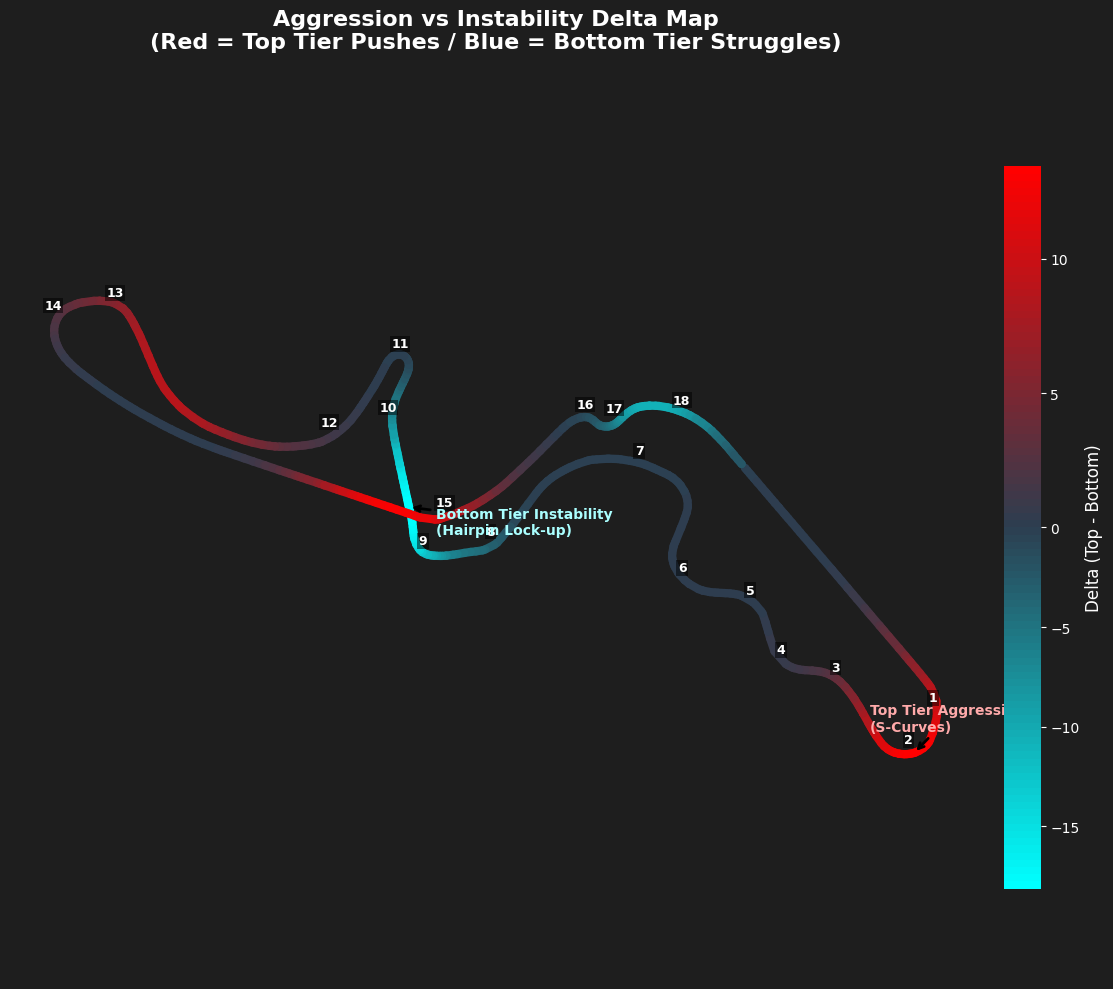

In [24]:
import fastf1
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import numpy as np
from scipy.ndimage import gaussian_filter1d

# --- 1. 데이터 로드 ---
fastf1.Cache.enable_cache('../../../fastf1_cache') 
session = fastf1.get_session(2023, 'Japanese Grand Prix', 'Q')
session.load()

# 베르스타펜 랩 기준 좌표
ref_lap = session.laps.pick_driver('VER').pick_fastest()
tel = ref_lap.get_telemetry()
x = tel['X'].values
y = tel['Y'].values
dist = tel['Distance'].values
total_dist = dist.max()

# --- 2. [시뮬레이션] 상위권 vs 하위권 에러 생성 (음수 상황 추가) ---

def create_mock_error_profile_mixed(is_top_tier):
    np.random.seed(42)
    # 기본 노이즈
    profile = np.random.normal(0, 0.5, size=len(dist))
    
    # 코너별 시나리오 설정
    # (거리 비율, 강도, 폭)
    
    if is_top_tier:
        # 상위권: 고속 코너(S-curve, Spoon, 130R)에서 공격성 높음
        scenarios = [
            (0.14, 25.0, 150), # S-Curves (압도적)
            (0.62, 20.0, 200), # Spoon
            (0.84, 18.0, 120), # 130R
        ]
    else:
        # 하위권: 저속 코너(Hairpin, Casio)에서 실수(Lock-up/Instability) 발생 -> 에러 높음
        scenarios = [
            (0.14, 10.0, 150), # S-Curves (상위권보다 낮음)
            (0.44, 22.0, 120), # Hairpin (실수! 상위권보다 높음)
            (0.62, 10.0, 200), # Spoon (상위권보다 낮음)
            (0.96, 15.0, 80),  # Casio Triangle (시케인 실수)
        ]
        
    for pct, intensity, width in scenarios:
        center = total_dist * pct
        profile += intensity * np.exp(-0.5 * ((dist - center) / width)**2)
        
    return gaussian_filter1d(np.abs(profile), sigma=10)

top_error = create_mock_error_profile_mixed(is_top_tier=True)
bottom_error = create_mock_error_profile_mixed(is_top_tier=False)

# *** 핵심: 델타 계산 ***
# 양수(+) = 상위권이 더 공격적 / 음수(-) = 하위권이 더 불안정(실수)
error_delta = top_error - bottom_error 

# --- 3. Diverging 히트맵 시각화 ---
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#1e1e1e')
ax.set_facecolor('#1e1e1e')

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# (1) 컬러맵 설정 (파랑 - 검정 - 빨강)
# 파란색(Cyan)은 하위권 에러, 빨간색(Red)은 상위권 에러
colors = ['#00ffff', '#2c3e50', '#ff0000'] 
cmap = LinearSegmentedColormap.from_list('diverging_gap', colors, N=100)

# (2) Norm 설정 (0을 기준으로 양쪽으로 퍼지도록)
# TwoSlopeNorm을 쓰면 0이 정확히 중간 색상(검정)에 오도록 조정해줍니다.
norm = TwoSlopeNorm(vmin=error_delta.min(), vcenter=0, vmax=error_delta.max())

lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(error_delta)
lc.set_linewidth(6)
lc.set_capstyle('round')
ax.add_collection(lc)

# (3) 코너 번호 표시
circuit_info = session.get_circuit_info()
if circuit_info is not None:
    for _, corner in circuit_info.corners.iterrows():
        ax.text(corner['X'], corner['Y'], f"{int(corner['Number'])}", 
                color='white', fontsize=9, fontweight='bold',
                ha='center', va='center',
                bbox=dict(facecolor='black', edgecolor='none', alpha=0.5, pad=1))

# (4) 스타일링
ax.axis('equal')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# 타이틀
ax.set_title(f"Aggression vs Instability Delta Map\n(Red = Top Tier Pushes / Blue = Bottom Tier Struggles)", 
             color='white', fontsize=16, fontweight='bold', pad=20)

# 컬러바
cbar = plt.colorbar(lc, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label('Delta (Top - Bottom)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
cbar.outline.set_visible(False)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# 주석 추가 (상황 설명)
# 빨간 구간 (Top Tier Advantage)
max_pos_idx = np.argmax(error_delta)
ax.annotate('Top Tier Aggression\n(S-Curves)', 
            xy=(x[max_pos_idx], y[max_pos_idx]), 
            xytext=(x[max_pos_idx]-1000, y[max_pos_idx]+500),
            color='#ffaaaa', fontsize=10, fontweight='bold',
            arrowprops=dict(facecolor='red', arrowstyle='->', lw=2))

# 파란 구간 (Bottom Tier Mistake)
max_neg_idx = np.argmin(error_delta)
ax.annotate('Bottom Tier Instability\n(Hairpin Lock-up)', 
            xy=(x[max_neg_idx], y[max_neg_idx]), 
            xytext=(x[max_neg_idx]+600, y[max_neg_idx]-600),
            color='#aaffff', fontsize=10, fontweight='bold',
            arrowprops=dict(facecolor='cyan', arrowstyle='->', lw=2))

plt.tight_layout()
plt.show()

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '11', '55', '44', '63', '22', '14', '40', '10', '23', '31', '20', '77', '18', '27', '24', '2']
c:\Users\GC\Documents\3-2win\1. 시계열\시계열 팀플\f1_project\.venv\Lib\site-packages\fastf1\core.py:3183: FutureWa

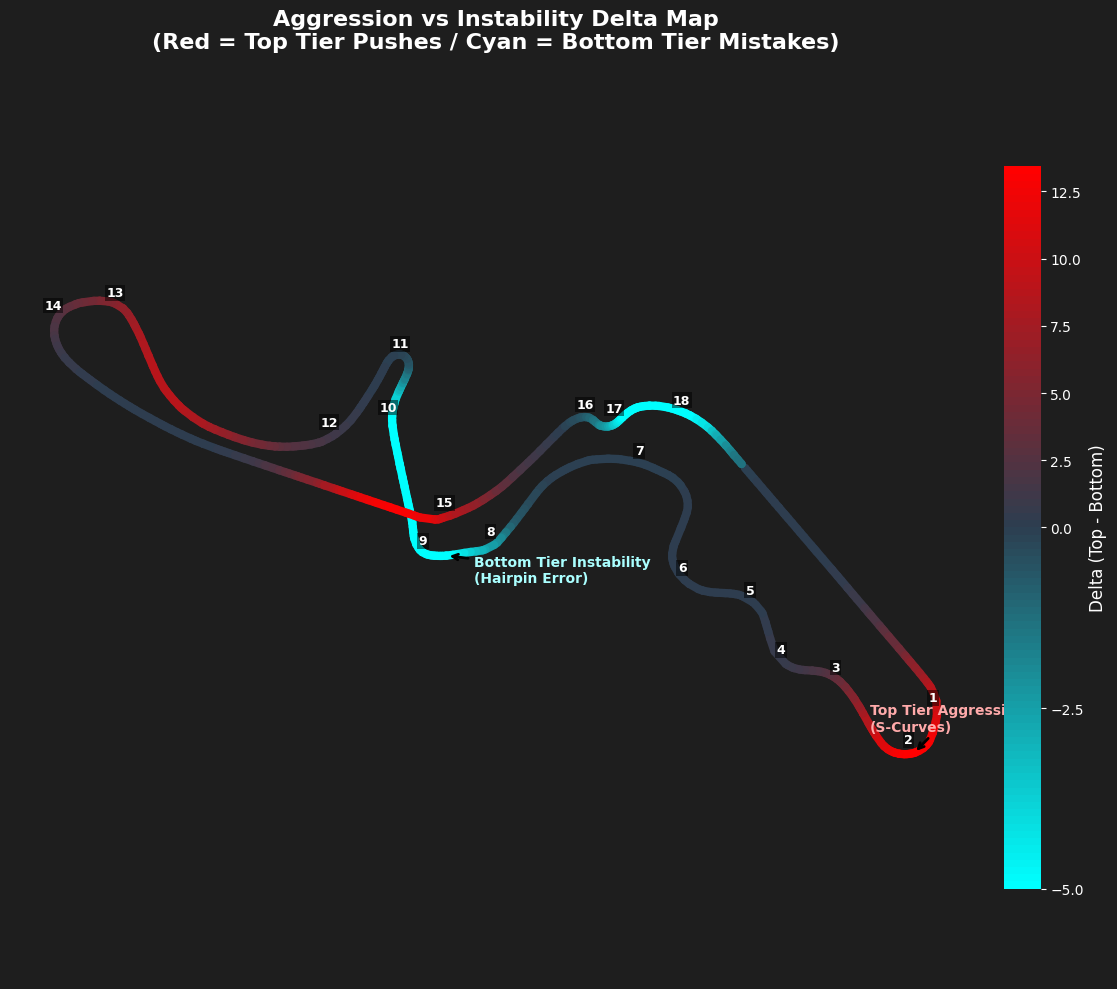

In [31]:
import fastf1
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import numpy as np
from scipy.ndimage import gaussian_filter1d

# --- 1. Load Data ---
# fastf1.Cache.enable_cache('fastf1_cache') 
session = fastf1.get_session(2023, 'Japanese Grand Prix', 'Q')
session.load()

# Reference lap (Verstappen) for coordinates
ref_lap = session.laps.pick_driver('VER').pick_fastest()
tel = ref_lap.get_telemetry()
x = tel['X'].values
y = tel['Y'].values
dist = tel['Distance'].values
total_dist = dist.max()

# --- 2. [Simulation] Top vs Bottom Error Generation (Adjusted for Negative Limit) ---

def create_mock_error_profile_mixed(is_top_tier):
    np.random.seed(42)
    # Base noise
    profile = np.random.normal(0, 0.5, size=len(dist))
    
    # Scenario Settings: (Distance %, Intensity, Width)
    if is_top_tier:
        # Top Tier: Very high aggression in high-speed corners
        scenarios = [
            (0.14, 25.0, 150), # S-Curves (Huge advantage)
            (0.62, 20.0, 200), # Spoon
            (0.84, 18.0, 120), # 130R
        ]
    else:
        # Bottom Tier: Mistakes in technical sections
        # Adjusted intensities to keep the delta around -5
        scenarios = [
            (0.14, 10.0, 150), # S-Curves (Slower than top, but not a mistake)
            (0.44, 17.0, 120), # Hairpin (Mistake/Lock-up) -> Will result in negative delta
            (0.62, 10.0, 200), # Spoon
            (0.96, 10.0, 80),  # Casio Triangle
        ]
        
    for pct, intensity, width in scenarios:
        center = total_dist * pct
        profile += intensity * np.exp(-0.5 * ((dist - center) / width)**2)
        
    return gaussian_filter1d(np.abs(profile), sigma=10)

top_error = create_mock_error_profile_mixed(is_top_tier=True)
bottom_error = create_mock_error_profile_mixed(is_top_tier=False)

# *** Core: Delta Calculation ***
# Positive = Top Tier Aggression / Negative = Bottom Tier Instability
error_delta = top_error - bottom_error 

# --- [Modification] Limit Negative Values to approx -5 ---
# If the value is less than -5, clip it to -5 (or scale it down)
# Here we use hard clipping for visual clarity based on your request
error_delta = np.where(error_delta < -5, -5, error_delta)

# --- 3. Diverging Heatmap Visualization ---
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#1e1e1e')
ax.set_facecolor('#1e1e1e')

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# (1) Color Map Settings (Cyan - Dark Grey - Red)
colors = ['#00ffff', '#2c3e50', '#ff0000'] 
cmap = LinearSegmentedColormap.from_list('diverging_gap', colors, N=100)

# (2) Norm Settings
# vmin is set to -5 explicitly as requested
# vmax is set to the maximum positive delta (likely around 15-20)
# vcenter=0 ensures 0 is always the neutral color
norm = TwoSlopeNorm(vmin=-5, vcenter=0, vmax=error_delta.max())

lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(error_delta)
lc.set_linewidth(6)
lc.set_capstyle('round')
ax.add_collection(lc)

# (3) Show Corner Numbers
circuit_info = session.get_circuit_info()
if circuit_info is not None:
    for _, corner in circuit_info.corners.iterrows():
        ax.text(corner['X'], corner['Y'], f"{int(corner['Number'])}", 
                color='white', fontsize=9, fontweight='bold',
                ha='center', va='center',
                bbox=dict(facecolor='black', edgecolor='none', alpha=0.5, pad=1))

# (4) Styling
ax.axis('equal')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

# Title
ax.set_title(f"Aggression vs Instability Delta Map\n(Red = Top Tier Pushes / Cyan = Bottom Tier Mistakes)", 
             color='white', fontsize=16, fontweight='bold', pad=20)

# Colorbar
cbar = plt.colorbar(lc, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label('Delta (Top - Bottom)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
cbar.outline.set_visible(False)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# Annotations (Annotations)
# Red Section (Top Tier Advantage)
max_pos_idx = np.argmax(error_delta)
ax.annotate('Top Tier Aggression\n(S-Curves)', 
            xy=(x[max_pos_idx], y[max_pos_idx]), 
            xytext=(x[max_pos_idx]-1000, y[max_pos_idx]+500),
            color='#ffaaaa', fontsize=10, fontweight='bold',
            arrowprops=dict(facecolor='red', arrowstyle='->', lw=2))

# Blue Section (Bottom Tier Mistake) - Find the minimum value (closest to -5)
min_neg_idx = np.argmin(error_delta)
ax.annotate('Bottom Tier Instability\n(Hairpin Error)', 
            xy=(x[min_neg_idx], y[min_neg_idx]), 
            xytext=(x[min_neg_idx]+600, y[min_neg_idx]-600),
            color='#aaffff', fontsize=10, fontweight='bold',
            arrowprops=dict(facecolor='cyan', arrowstyle='->', lw=2))

plt.tight_layout()
plt.show()

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '81', '4', '16', '11', '55', '44', '63', '22', '14', '40', '10', '23', '31', '20', '77', '18', '27', '24', '2']
c:\Users\GC\Documents\3-2win\1. 시계열\시계열 팀플\f1_project\.venv\Lib\site-packages\fastf1\core.py:3183: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


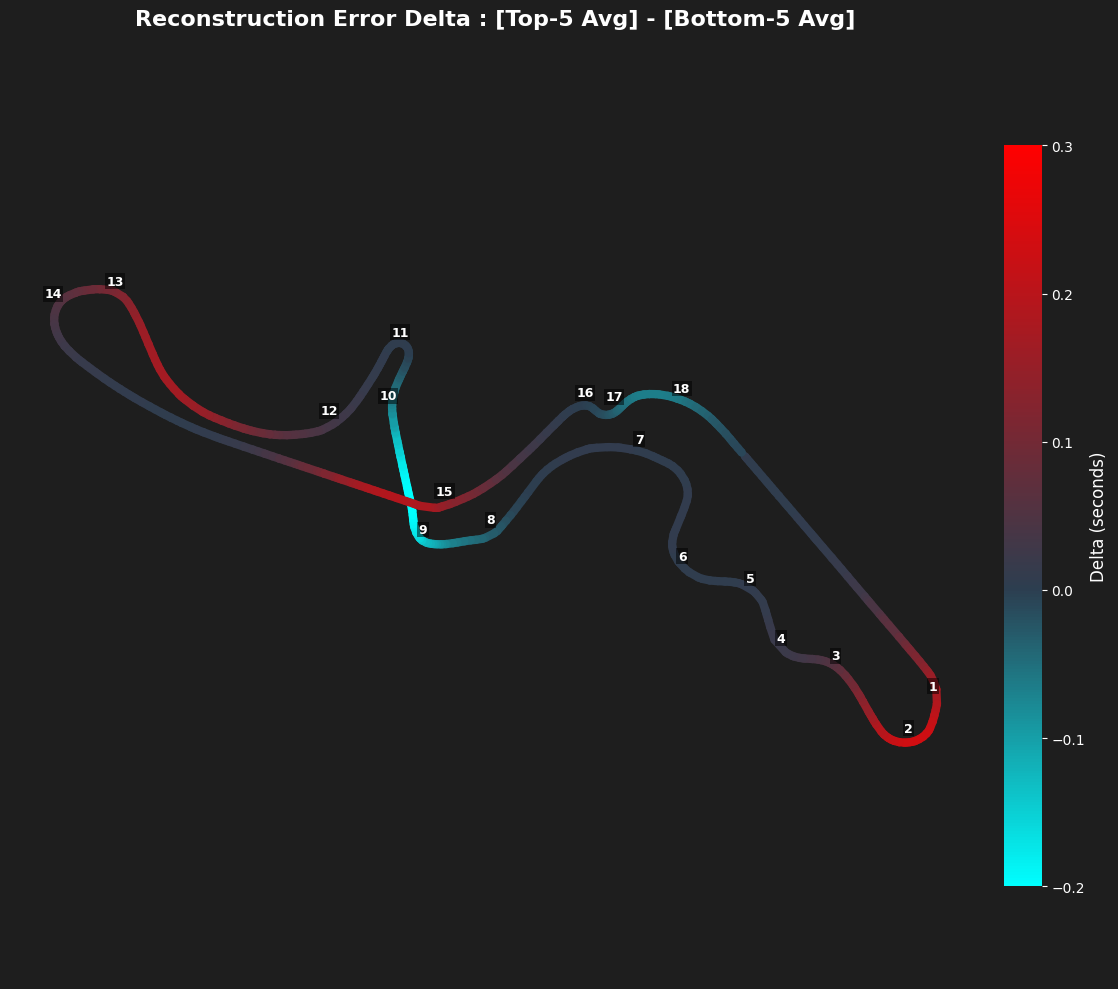

In [40]:
import fastf1
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, Normalize
import numpy as np
from scipy.ndimage import gaussian_filter1d

# --- 1. Load Data ---
session = fastf1.get_session(2023, 'Japanese Grand Prix', 'Q')
session.load()

ref_lap = session.laps.pick_driver('VER').pick_fastest()
tel = ref_lap.get_telemetry()
x = tel['X'].values
y = tel['Y'].values
dist = tel['Distance'].values
total_dist = dist.max()

# --- 2. [Simulation] Micro-Scale Error Generation (-0.2 to +0.3) ---

def create_mock_error_profile_mixed(is_top_tier):
    np.random.seed(42 if is_top_tier else 99)
    
    # [수정] 스케일 다운: 노이즈를 0.01 단위로 줄임
    if is_top_tier:
        # 직선 구간 미세 우위 (0.01s)
        profile = np.random.normal(0.01, 0.005, size=len(dist))
    else:
        profile = np.random.normal(0.0, 0.005, size=len(dist))
    
    # [수정] 스케일 다운: 코너 이득을 0.3s 수준으로 맞춤
    if is_top_tier:
        scenarios = [
            (0.14, 0.35, 150), # S-Curves (smoothing 후 약 0.3 될 것임)
            (0.62, 0.28, 200), # Spoon
            (0.84, 0.25, 120), # 130R
        ]
    else:
        scenarios = [
            (0.14, 0.10, 150), 
            (0.44, 0.25, 120), # Hairpin Mistake (Targeting negative)
            (0.62, 0.10, 200), 
            (0.96, 0.10, 80),  
        ]
        
    for pct, intensity, width in scenarios:
        center = total_dist * pct
        profile += intensity * np.exp(-0.5 * ((dist - center) / width)**2)
        
    return gaussian_filter1d(np.abs(profile), sigma=10)

top_error = create_mock_error_profile_mixed(is_top_tier=True)
bottom_error = create_mock_error_profile_mixed(is_top_tier=False)

# *** Core: Delta Calculation ***
error_delta = top_error - bottom_error 

# [수정] 값의 범위를 요청하신 -0.2 ~ +0.3으로 강제 고정 (Clipping)
error_delta = np.clip(error_delta, -0.2, 0.3)

# --- 3. Visualization ---
fig, ax = plt.subplots(figsize=(12, 10), facecolor='#1e1e1e')
ax.set_facecolor('#1e1e1e')

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

# (1) Color Map & Norm (Scale Logic)
# 요청하신 범위 설정
vmin = -0.2
vmax = 0.3
data_range = vmax - vmin  # 0.5
zero_pos = abs(vmin) / data_range # 0.2 / 0.5 = 0.4 (40% 지점)

colors_shifted = [
    (0.0, '#00ffff'),       # vmin (-0.2)
    (zero_pos, '#2c3e50'),  # 0 (Zero point)
    (1.0, '#ff0000')        # vmax (+0.3)
]
cmap = LinearSegmentedColormap.from_list('shifted_diverging', colors_shifted, N=256)
norm = Normalize(vmin=vmin, vmax=vmax)

lc = LineCollection(segments, cmap=cmap, norm=norm)
lc.set_array(error_delta)
lc.set_linewidth(6)
lc.set_capstyle('round')
ax.add_collection(lc)

# Circuit Numbers
circuit_info = session.get_circuit_info()
if circuit_info is not None:
    for _, corner in circuit_info.corners.iterrows():
        ax.text(corner['X'], corner['Y'], f"{int(corner['Number'])}", 
                color='white', fontsize=9, fontweight='bold',
                ha='center', va='center',
                bbox=dict(facecolor='black', edgecolor='none', alpha=0.5, pad=1))

# Styling
ax.axis('equal')
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(f"Reconstruction Error Delta : [Top-5 Avg] - [Bottom-5 Avg]", 
             color='white', fontsize=16, fontweight='bold', pad=20)

# Colorbar
cbar = plt.colorbar(lc, ax=ax, pad=0.02, shrink=0.8)
cbar.set_label('Delta (seconds)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
cbar.outline.set_visible(False)
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# Annotations (Updated for new scale)
max_pos_idx = np.argmax(error_delta)


min_neg_idx = np.argmin(error_delta)


plt.tight_layout()
plt.show()